In [1]:
from langchain_groq import ChatGroq
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.tools import tool
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
import base64
import cv2
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Any
import numpy as np
import os
import matplotlib.pyplot as plt
import pyautogui
import time
from inference_sdk import InferenceHTTPClient
import json

In [4]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [19]:
global_image_path_for_ss="image_test.png"

In [ ]:
class Obstacle_handler(TypedDict):
    image_path:str 
    explanation:str
    index_number: None
    buttons_coord_list:list

def find_buttons_and_text(state: Obstacle_handler) -> Obstacle_handler:

    result=CLIENT.infer(state["image_path"], model_id="sv-gui-v1.1/2")#"gui-kjay8/11")

    img = cv2.imread(state["image_path"])
    images = []       
    button_centers=[]


    for ele in result["predictions"]:
        if ele["class"] in ["icon", "button"] and ele["confidence"]>0.0:
            x_center = ele["x"]
            y_center = ele["y"]
            w = ele["width"]
            h = ele["height"]

            x1 = int(x_center - w / 2)
            y1 = int(y_center - h / 2)
            x2 = int(x_center + w / 2)
            y2 = int(y_center + h / 2)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img.shape[1], x2)
            y2 = min(img.shape[0], y2)

            crop=img[y1:y2, x1:x2]
            crop = cv2.copyMakeBorder(
                crop,
                top=5,
                bottom=5,
                left=5,
                right=5,
                borderType=cv2.BORDER_CONSTANT,
                value=(0, 0, 0)  
            )
            center_x = int(x_center)
            center_y = int(y_center)
    
            button_centers.append((center_x, center_y))
            images.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

        

    start=0
    end=6
    for i in range(0, len(images), 6):
        fig, axes = plt.subplots(2, 3, figsize=(18, 18))

        for idx, (ax, image) in enumerate(zip(axes.ravel(), images[start:end])):

            image_idx = start + idx


            ax.imshow(image)
            ax.text(
                0.0, 1.05,
                str(image_idx),
                transform=ax.transAxes,
                fontsize=48,
                fontweight="bold",
                ha="left",
                va="bottom"
            )

            ax.axis("off")

        for ax in axes.ravel()[len(images[start:end]):]:
            ax.axis("off")

        plt.tight_layout()

        plt.savefig(
            f"Test_image_folder/buttons_image{i}.png",
            bbox_inches="tight",
            pad_inches=0,
            dpi=300
        )
        start+=end
        end+=6
    state["buttons_coord_list"]=button_centers
    return state


def understand_explanation(state: Obstacle_handler)->Obstacle_handler:
    prompt=ChatPromptTemplate.from_messages([("system",
                                              """
You are an intelligent human web-navigation assistant.

Your task is to inspect the provided catalogue of cropped button images and identify the SINGLE button that best satisfies the user's requirement.

IMPORTANT RULES:

1. The number displayed above each button image is its INDEX.
2. Return ONLY the INDEX of the selected button.
3. Choose a button only if it is a strong semantic match to the user's intent.
4. Prefer precision over recall:
   - If uncertain, return NONE.
   - Do not guess.
5. Match based on the visible button text, meaning, and common human interpretation.
7. If multiple buttons appear relevant, select the one that most directly fulfills the user's request.
8. Ignore decorative elements, icons, borders, colors, and layout unless they help identify the button meaning.
9. Never select a button that contradicts the user's goal.
10. If no suitable button exists in the catalogue, return NONE.

OUTPUT RULES:

- Return only a single INDEX (e.g. 0, 3, 12)
OR
- Return NONE

DO NOT:
- Explain your choice.
- Add reasoning.
- Add punctuation.
- Add quotes.
- Add markdown.
- Output anything except the INDEX or NONE.

Examples:

USER: A cookie consent popup appeared. Accept all cookies.
OUTPUT:
0

USER: A newsletter subscription popup appeared. Close it.
OUTPUT:
2

USER: Select the button to continue to the next step.
OUTPUT:
5

USER: No button matches the request.
OUTPUT:
NONE                                          
"""), 
("human", [{"type":"text", "text":"USER: {query}"},
           {"type":"image", "image_url":{"url":"data:image/jpeg;base64,{base64_image}"}}])])
    


    chain=prompt | vlm_model | StrOutputParser()
    for _, dirs, files in os.walk("Test_image_folder"):
        for f in files:
            image_path=os.path.join("Test_image_folder", f)
            base64_image=encode_image(image_path)

            output=chain.invoke({
                "query": state["explanation"],
                "base64_image": base64_image
            })


            try:
                int(str(output).strip())
                print ("Index Output found: ", output)

                state["index_number"]=int(str(output).strip())
                break
            except Exception as e:   
                print (output)
    return state



def find_relevant_text(state: Obstacle_handler)->Obstacle_handler:


    print ("===============Insidet find relevant text=================")
    prompt= ChatPromptTemplate.from_messages([("system", """

        You are an intelligent human replica, who is applying for the jobs.

        You have been called because there is some obstacle in the webpage, you have to look at the screenshot of the page and decide what has to be done to solve the issue.

        Try to suggest that you should be closing the problem, dont make it as a whole workflow, try to keep it simple, such that when clicked a single button it solves the issue   

        Check the button in such a way that it solves the issue quickly as possible.                                    
        
        There is another person who could only see the buttons in the given screenshot so, he would be understanding your interpretation and clicking on the button based on what you say.

        So make sure your interpretaion is right.

        Dont make the explanation too long keep it enough that it carries enough information. 

        No extra explanation needed.                                                                           
    """),
    ("human", [{
        "type":"text",
        "text": "Analyze the following image"
    },
    {"type":"image", "image_url": {
        "url":"data:image/jpeg;base64,{base64_image}"}
    }]), ("assistant", "Button to be clicked:")])

    chain=prompt | vlm_model | StrOutputParser()


    base64_image=encode_image(state["image_path"])
    state["explanation"]=chain.invoke({
        "base64_image":base64_image
    })

    print (state["explanation"])
    
    
    return state




graph=StateGraph(Obstacle_handler)

graph.add_node("find_buttons_and_text", find_buttons_and_text)
graph.add_node("understand_explanation", understand_explanation)
graph.add_node("find_relevant_text", find_relevant_text)
graph.set_entry_point("find_relevant_text")


graph.add_edge("find_relevant_text", "find_buttons_and_text")
graph.add_edge("find_buttons_and_text", "understand_explanation")
graph.add_edge("understand_explanation", END)

app=graph.compile()

In [21]:
@tool
def is_obstacle_present(screen_summary: str) -> str:
    """
    LOW PRIORITY FALLBACK TOOL.

    Use ONLY when an obstacle exists and it is NOT:
    - Login popup
    - Signup popup
    - Authentication wall

    If login-related UI is present,
    use login_page instead.

    """

    image_path=global_image_path_for_ss
    graph_output=app.invoke({
        "image_path":image_path,
    })

    buttons_index=graph_output["index_number"]
    buttons_coord=graph_output["buttons_coord_list"]

    print("Starting")
    time.sleep(5)
    pyautogui.click(buttons_coord[buttons_index])
    
    return graph_output
                

    
@tool
def login_page(screen_summary:str)->None:
    """
    HIGH PRIORITY TOOL.

    Use this tool whenever the screen contains:
    - Sign in
    - Log in
    - Continue with Google
    - Continue with Email
    - Create Account
    - Sign Up

    If a login or signup dialog is present,
    ALWAYS use this tool instead of is_obstacle_present.

    """
    print ("LOGIN OBSTACLE")
    




@tool
def no_obstacle(screen_summary: str) -> str:
    """
    Use this tool ONLY when the job application workflow is accessible
    and no blocking UI element is present.

    Call this tool when:
    - An Apply button is visible.
    - A job description is visible.
    - An application form is visible.
    - Resume upload fields are accessible.
    - Submit/Next buttons are accessible.
    - The page can be interacted with normally.

    DO NOT call this tool when:
    - A popup covers the page.
    - A login wall blocks access.
    - A consent banner prevents interaction.
    - A modal or overlay must first be dismissed.

    Returns:
        Confirmation that the application flow can continue.
    """
    return "NO_OBSTACLE_PRESENT"

In [22]:
tools=[is_obstacle_present, no_obstacle]


prompt=ChatPromptTemplate.from_messages([(
    "system", "You are an expert job seeking human, you have to apply to the job, you will be provided with the screenshot to find in the fields."
),

("human", [
    {"type":"text", "text":"Here is the job page screenshot"},
    {"type":"image_url", "image_url":{
        "url":"data:image/jpeg;base64,{base64_image}"
    }}
]), MessagesPlaceholder("agent_scratchpad")])
agent=create_tool_calling_agent(llm=vlm_model, tools=tools, prompt=prompt)


agent_exe=AgentExecutor(agent=agent, tools=tools, verbose=True, max_iterations=2)

In [16]:
result=agent_exe.invoke({
    "base64_image":base64_image
})

NameError: name 'base64_image' is not defined

In [ ]:
CLIENT.infer("image.png", model_id="gui-kjay8/11")

In [23]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
driver_path = r"chromedriver.exe"


service = Service(driver_path)

In [ ]:
from langchain.chains.base import Chain

class ss_custom_chain(Chain):
    @property
    def input_keys(self):
        return ["path"]

    @property
    def output_keys(self):
        return ["base64_image"]

    def _call(self, inputs, run_manager = None):
        driver.save_screenshot(inputs["path"])
        base64_image=encode_image(inputs["path"])
        return {"base64_image":base64_image}
    
ss_runnable=ss_custom_chain()
last_page="no"

@tool
def confirmed_move_down()->str:

    """Use this tool to move down in the current webpage and obtain the next set of screenshot, to read what is in it."""
    driver.execute_script(
        "window.scrollBy(0, window.innerHeight * 0.9);"
    )
    if driver.execute_script(
        "return window.innerHeight + window.pageYOffset >= document.body.scrollHeight - 10"
    ):
       global last_page
       last_page="yes"

    os.remove(global_image_path_for_ss)
    driver.save_screenshot(global_image_path_for_ss)
    return "Done saving the screenshot of the next website image"


@tool
def confirmed_obstacle()->str:
    """Use this tool to solve the Pop up or obstacle issue."""

    base64_image=encode_image(global_image_path_for_ss)

    result=agent_exe.invoke({
        "base64_image":base64_image
    })

    

    return "The obstacle has been removed."

@tool
def providing_help_through_vision()->str:

    """Use this tool to use the help of human vision, where human would tell what is present in the screen. Use this tool only when you are not able to come to conclusion what is present in the screen."""
    prompt=ChatPromptTemplate.from_messages([
        ("system", """

You are an intelligent human replica. You are assigned a task to define what is present in the screen in a brief manner.
         
         Earlier an human tried to understand what is in the screen using text, but was not able to understand them, hence your jpb is to explain what is in the current screenshot

Keep the explanation brief and short.
"""),
    ("human", [{
        "type":"text",
        "text": "Analyze the following image"
    },
    {"type":"image", "image_url": {
        "url":"data:image/jpeg;base64,{base64_image}"}
    }])])


    base64_image=encode_image(global_image_path_for_ss)
    chain=prompt | vlm_model | StrOutputParser()

    output=chain.invoke({
        "base64_image": base64_image
    })

    return output
tools=[confirmed_move_down, confirmed_obstacle]


main_prompt=ChatPromptTemplate.from_messages([("system", """
You are the visual understanding module of a human-like web navigation agent.

The agent is trying to accomplish a user goal on a website.

Analyze the screenshot and explain the page from the perspective of progressing toward the user's goal.

Focus on:

- What this page appears to be.
- How this page relates to the user's objective.
- What information is currently important.
- Whether the goal can be progressed from the current page.
- What opportunities are visible for moving closer to the goal.
- Whether additional navigation, scrolling, form filling, or selection may be required.

Think like an intelligent human who is trying to complete the task.

Do not enumerate every UI element.
Do not describe colors, styling, spacing, or coordinates.
Do not provide pixel-level observations.
Do not describe the screenshot mechanically.

Instead explain the meaning of the page and its relevance to the user's goal.

Examples:

User Goal:
"Apply for a Software Engineer position"

Output:
"The user is currently on a job listing page displaying a Software Engineer role. The job description and application-related information are visible, and the page appears relevant to the objective. Additional scrolling may reveal application requirements or a way to begin the application process."

User Goal:
"Submit an application"

Output:
"The page appears to be part of an application workflow. Information requested from the applicant is visible, and progress toward submission will likely require completing the requested details before continuing."

User Goal:
"Find available jobs"

Output:
"The page shows a collection of job opportunities. The current state allows the user to review positions and identify roles that match their interests before navigating to a specific application."

Keep the explanation concise but sufficiently detailed for another intelligent agent to decide the next action.
"""), ("human", [{
        "type":"text",
        "text": "Analyze the following image"
    },
    {"type":"image", "image_url": {
        "url":"data:image/jpeg;base64,{base64_image}"}
    }]), MessagesPlaceholder("agent_scratchpad")])
model=create_tool_calling_agent(llm=vlm_model, tools=tools, prompt=main_prompt)

agent=AgentExecutor(tools=tools, agent=model, verbose=True)

chain=ss_runnable | agent
driver = webdriver.Chrome(service=service)
driver.get("https://thestampmarket.com/")


if input("text")=="y":
    print ("Waiting for 5 seconds")
    time.sleep(5)
    chain.invoke({
        "path":global_image_path_for_ss
    })


# =========================================================================

In [15]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
#from selenium.webdriver.common.exceptions import ElementNotInteractableException
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
def get_clickable_xpath_by_text(driver, text):

    script = """
    function getXPath(element) {
        if (element.id)
            return '//*[@id="' + element.id + '"]';

        if (element === document.body)
            return '/html/body';

        let ix = 0;
        const siblings = element.parentNode.childNodes;

        for (let i = 0; i < siblings.length; i++) {
            const sibling = siblings[i];

            if (sibling === element) {
                return getXPath(element.parentNode) +
                    '/' + element.tagName.toLowerCase() +
                    '[' + (ix + 1) + ']';
            }

            if (
                sibling.nodeType === 1 &&
                sibling.tagName === element.tagName
            ) {
                ix++;
            }
        }
    }

    const target = arguments[0].trim().toLowerCase();

    const candidates = document.querySelectorAll(
        'button,a,input,[role="button"]'
    );

    for (const el of candidates) {

        const text =
            (el.innerText ||
             el.value ||
             el.getAttribute('aria-label') ||
             '').trim().toLowerCase();

        if (text === target) {
            return getXPath(el);
        }
    }

    return null;
    """


    return driver.execute_script(script, text)


In [16]:
def get_interactive_elements(driver):
    elements = driver.execute_script("""
function getXPath(el) {

    if (el.id)
        return `//*[@id="${el.id}"]`;

    let path = [];

    while (el && el.nodeType === 1) {

        let index = 1;

        let sibling = el.previousElementSibling;

        while (sibling) {
            if (sibling.tagName === el.tagName)
                index++;

            sibling = sibling.previousElementSibling;
        }

        path.unshift(
            el.tagName.toLowerCase() +
            "[" + index + "]"
        );

        el = el.parentElement;
    }

    return "/" + path.join("/");
}


let selectors = `
button,
a,
input,
textarea,
select,
[role="button"],
[role="link"],
[onclick],
[tabindex]
`;

let nodes = document.querySelectorAll(selectors);

let results = [];

nodes.forEach(el => {

    let rect = el.getBoundingClientRect();

    let visible =
        rect.width > 0 &&
        rect.height > 0 &&
        window.getComputedStyle(el).display !== "none" &&
        window.getComputedStyle(el).visibility !== "hidden";

    if (!visible)
        return;

    let text =
        el.innerText ||
        el.value ||
        el.placeholder ||
        el.getAttribute("aria-label") ||
        "";

    results.push({

        tag: el.tagName.toLowerCase(),

        text: text.trim(),

        aria_label:
            el.getAttribute("aria-label") || "",

        placeholder:
            el.getAttribute("placeholder") || "",

        name:
            el.getAttribute("name") || "",

        type:
            el.getAttribute("type") || "",

        xpath:
            getXPath(el)
    });

});

return results;
""")


    for idx, ele in enumerate(elements):
        ele["index"] = idx

    return(json.loads(json.dumps(elements, indent=2)))

In [17]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [11]:
class Obstacle_handler(TypedDict):
    image_path:str 
    explanation:str
    index_number: None
    buttons_coord_list:list
    driver: Any

def find_buttons_and_text(state: Obstacle_handler) -> Obstacle_handler:

    result=CLIENT.infer(state["image_path"], model_id="sv-gui-v1.1/2")#"gui-kjay8/11")

    img = cv2.imread(state["image_path"])
    images = []       
    button_centers=[]


    for ele in result["predictions"]:
        if ele["class"] in ["icon", "button"] and ele["confidence"]>0.0:
            x_center = ele["x"]
            y_center = ele["y"]
            w = ele["width"]
            h = ele["height"]

            x1 = int(x_center - w / 2)
            y1 = int(y_center - h / 2)
            x2 = int(x_center + w / 2)
            y2 = int(y_center + h / 2)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img.shape[1], x2)
            y2 = min(img.shape[0], y2)

            crop=img[y1:y2, x1:x2]
            crop = cv2.copyMakeBorder(
                crop,
                top=5,
                bottom=5,
                left=5,
                right=5,
                borderType=cv2.BORDER_CONSTANT,
                value=(0, 0, 0)  
            )
            center_x = int(x_center)
            center_y = int(y_center)
    
            button_centers.append((center_x, center_y))
            images.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

        

    start=0
    end=6
    for i in range(0, len(images), 6):
        fig, axes = plt.subplots(2, 3, figsize=(18, 18))

        for idx, (ax, image) in enumerate(zip(axes.ravel(), images[start:end])):

            image_idx = start + idx


            ax.imshow(image)
            ax.text(
                0.0, 1.05,
                str(image_idx),
                transform=ax.transAxes,
                fontsize=48,
                fontweight="bold",
                ha="left",
                va="bottom"
            )

            ax.axis("off")

        for ax in axes.ravel()[len(images[start:end]):]:
            ax.axis("off")

        plt.tight_layout()

        plt.savefig(
            f"Test_image_folder/buttons_image{i}.png",
            bbox_inches="tight",
            pad_inches=0,
            dpi=300
        )
        start+=end
        end+=6
    state["buttons_coord_list"]=button_centers
    return state


def understand_explanation(state: Obstacle_handler)->Obstacle_handler:
    prompt=ChatPromptTemplate.from_messages([("system",
                                              """
You are an intelligent human web-navigation assistant.

Your task is to inspect the provided catalogue of cropped button images and identify the SINGLE button that best satisfies the user's requirement.

IMPORTANT RULES:

1. The number displayed above each button image is its INDEX.
2. Return ONLY the INDEX of the selected button.
3. Choose a button only if it is a strong semantic match to the user's intent.
4. Prefer precision over recall:
   - If uncertain, return NONE.
   - Do not guess.
5. Match based on the visible button text, meaning, and common human interpretation.
7. If multiple buttons appear relevant, select the one that most directly fulfills the user's request.
8. Ignore decorative elements, icons, borders, colors, and layout unless they help identify the button meaning.
9. Never select a button that contradicts the user's goal.
10. If no suitable button exists in the catalogue, return NONE.

OUTPUT RULES:

- Return only a single INDEX (e.g. 0, 3, 12)
OR
- Return NONE

DO NOT:
- Explain your choice.
- Add reasoning.
- Add punctuation.
- Add quotes.
- Add markdown.
- Output anything except the INDEX or NONE.

Examples:

USER: A cookie consent popup appeared. Accept all cookies.
OUTPUT:
0

USER: A newsletter subscription popup appeared. Close it.
OUTPUT:
2

USER: Select the button to continue to the next step.
OUTPUT:
5

USER: No button matches the request.
OUTPUT:
NONE                                          
"""), 
("human", [{"type":"text", "text":"USER: {query}"},
           {"type":"image", "image_url":{"url":"data:image/jpeg;base64,{base64_image}"}}])])
    


    chain=prompt | vlm_model | StrOutputParser()
    for _, dirs, files in os.walk("Test_image_folder"):
        for f in files:
            image_path=os.path.join("Test_image_folder", f)
            base64_image=encode_image(image_path)

            output=chain.invoke({
                "query": state["explanation"],
                "base64_image": base64_image
            })


            try:
                int(str(output).strip())
                print ("Index Output found: ", output)

                state["index_number"]=int(str(output).strip())
                break
            except Exception as e:   
                print (output)
    return state

def perform_click(state: Obstacle_handler)->Obstacle_handler:
    driver = state["driver"]

    idx = state["index_number"]

    if idx is None:
        return state

    x, y = state["buttons_coord_list"][idx]
    dpr = driver.execute_script("return window.devicePixelRatio")

    x = x / dpr
    y = y / dpr

    driver.execute_script("""
        const ele = document.elementFromPoint(arguments[0], arguments[1]);
        if(ele){
            ele.click();
        }
    """, x, y)

    return state
graph=StateGraph(Obstacle_handler)

graph.add_node("find_buttons_and_text", find_buttons_and_text)
graph.add_node("understand_explanation", understand_explanation)
graph.add_node("perform_click", perform_click)
graph.set_entry_point("find_buttons_and_text")


graph.add_edge("find_buttons_and_text", "understand_explanation")
graph.add_edge("understand_explanation", "perform_click")
graph.add_edge("perform_click", END)

app=graph.compile()

In [13]:
global_image_path_for_ss="test_image_path.png"



> Entering new AgentExecutor chain...

Invoking: `find_visual_element_index` with `{'image_button_to_be_clicked': 'close button'}`
responded: The image shows a modal window with a sign-up offer. The modal window has a white background and contains the following elements:

* A pink banner at the top-left corner with the text "One time offer" in white.
* A purple illustration of an open book with stars above it.
* The heading "Sign up now to unlock" in black text.
* Two bullet points:
	+ "FREE AI Career Guide worth ₹599"
	+ "Custom job alerts delivered to your inbox"
* A timer that reads "Valid only for 04m : 52s".
* A paragraph of text that reads "By signing up, you agree to our Terms and Conditions."
* Two buttons:
	+ "Sign up with Google"
	+ "Sign up with Email"

The modal window appears to be blocking the view of a webpage with job listings.

To proceed, I need to close the modal window. I will attempt to find the close button.



NONE
Index Output found:  6
{'image_path': 'test_im

KeyError: 'index_number'

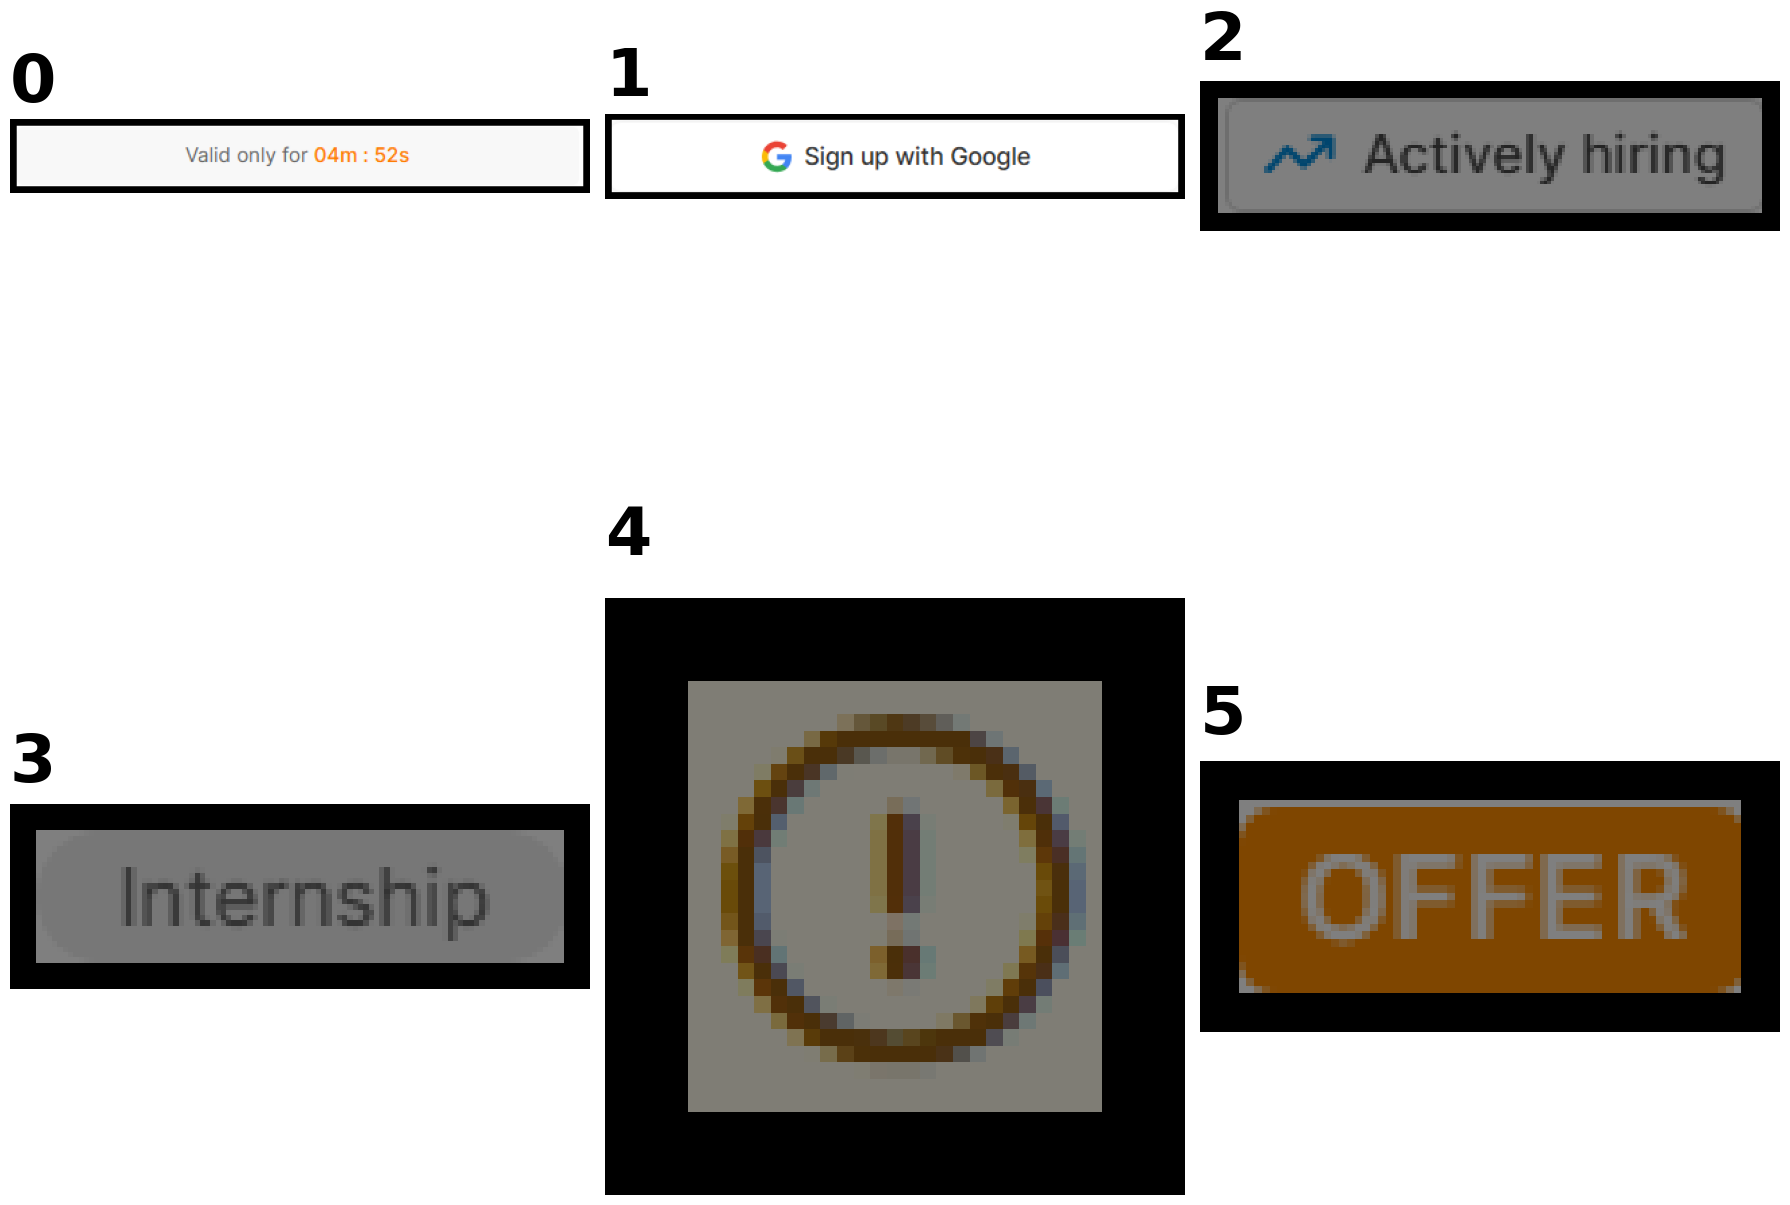

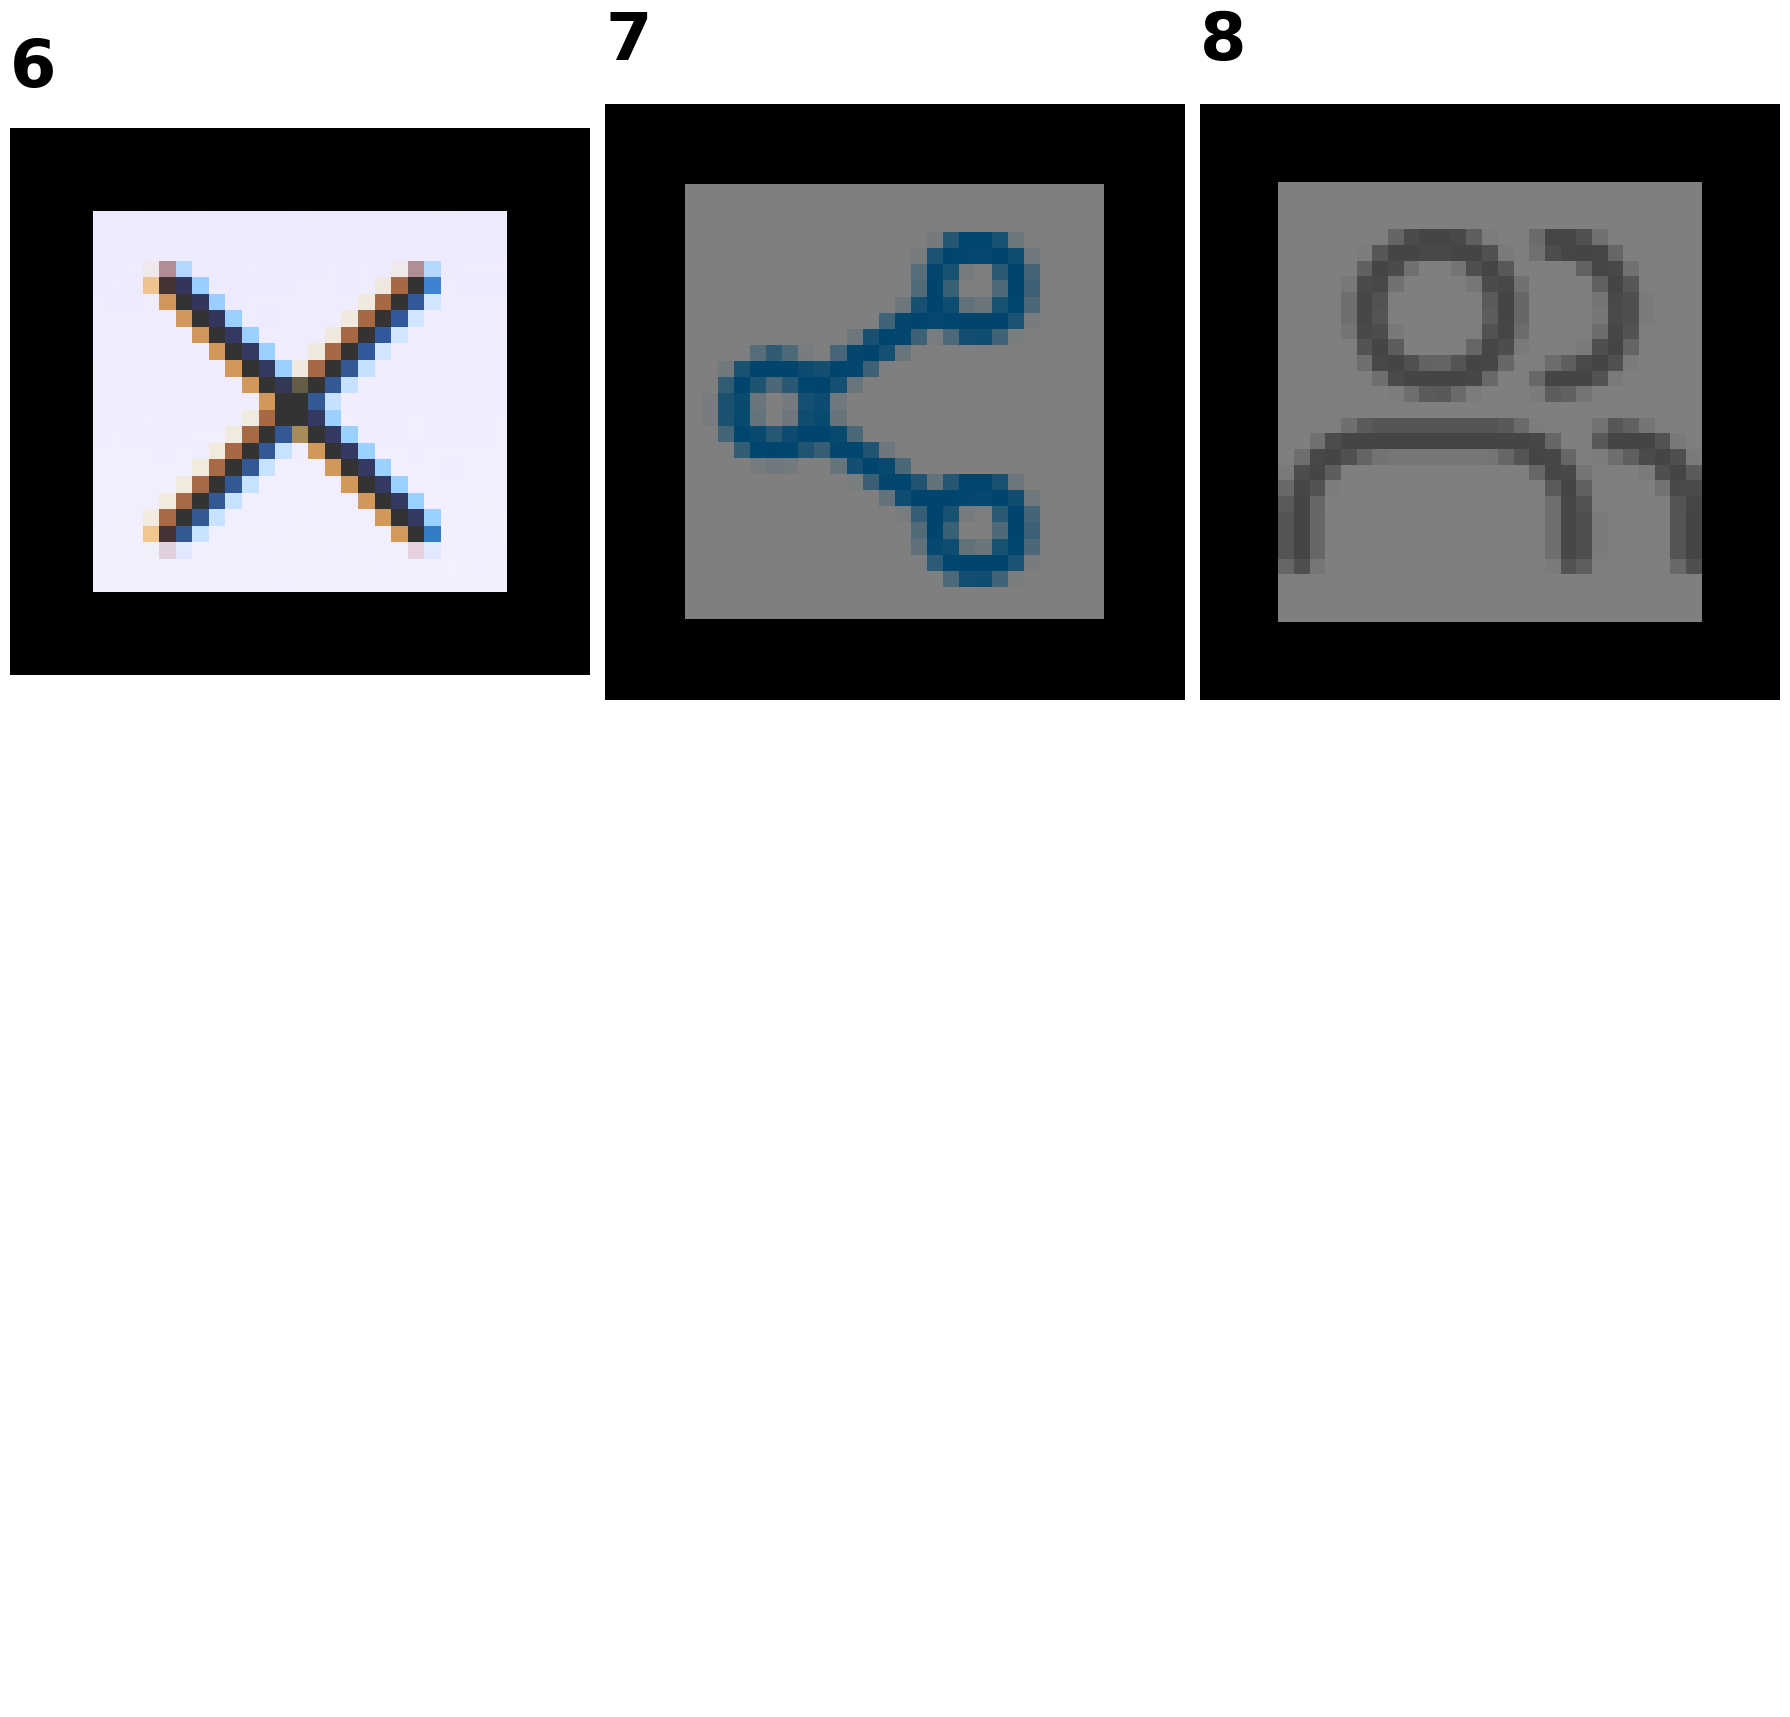

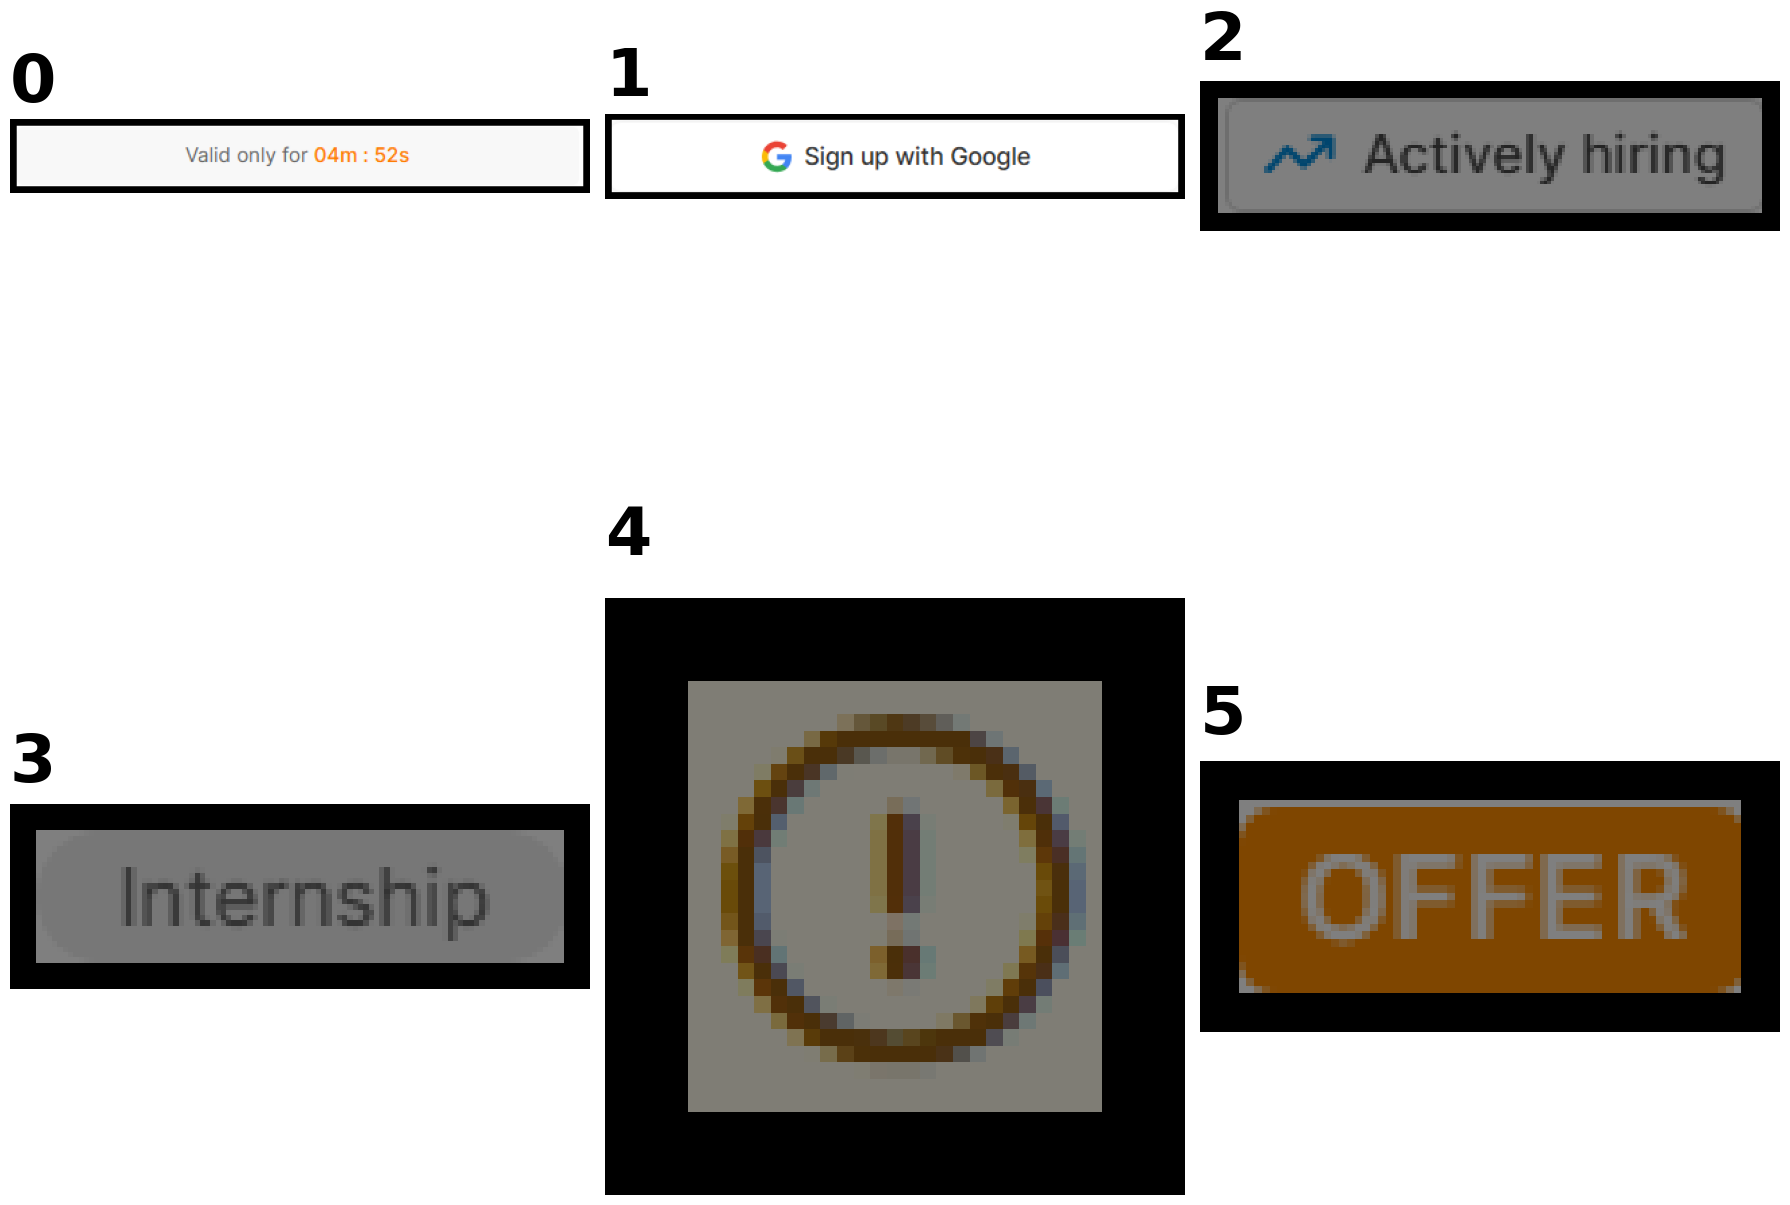

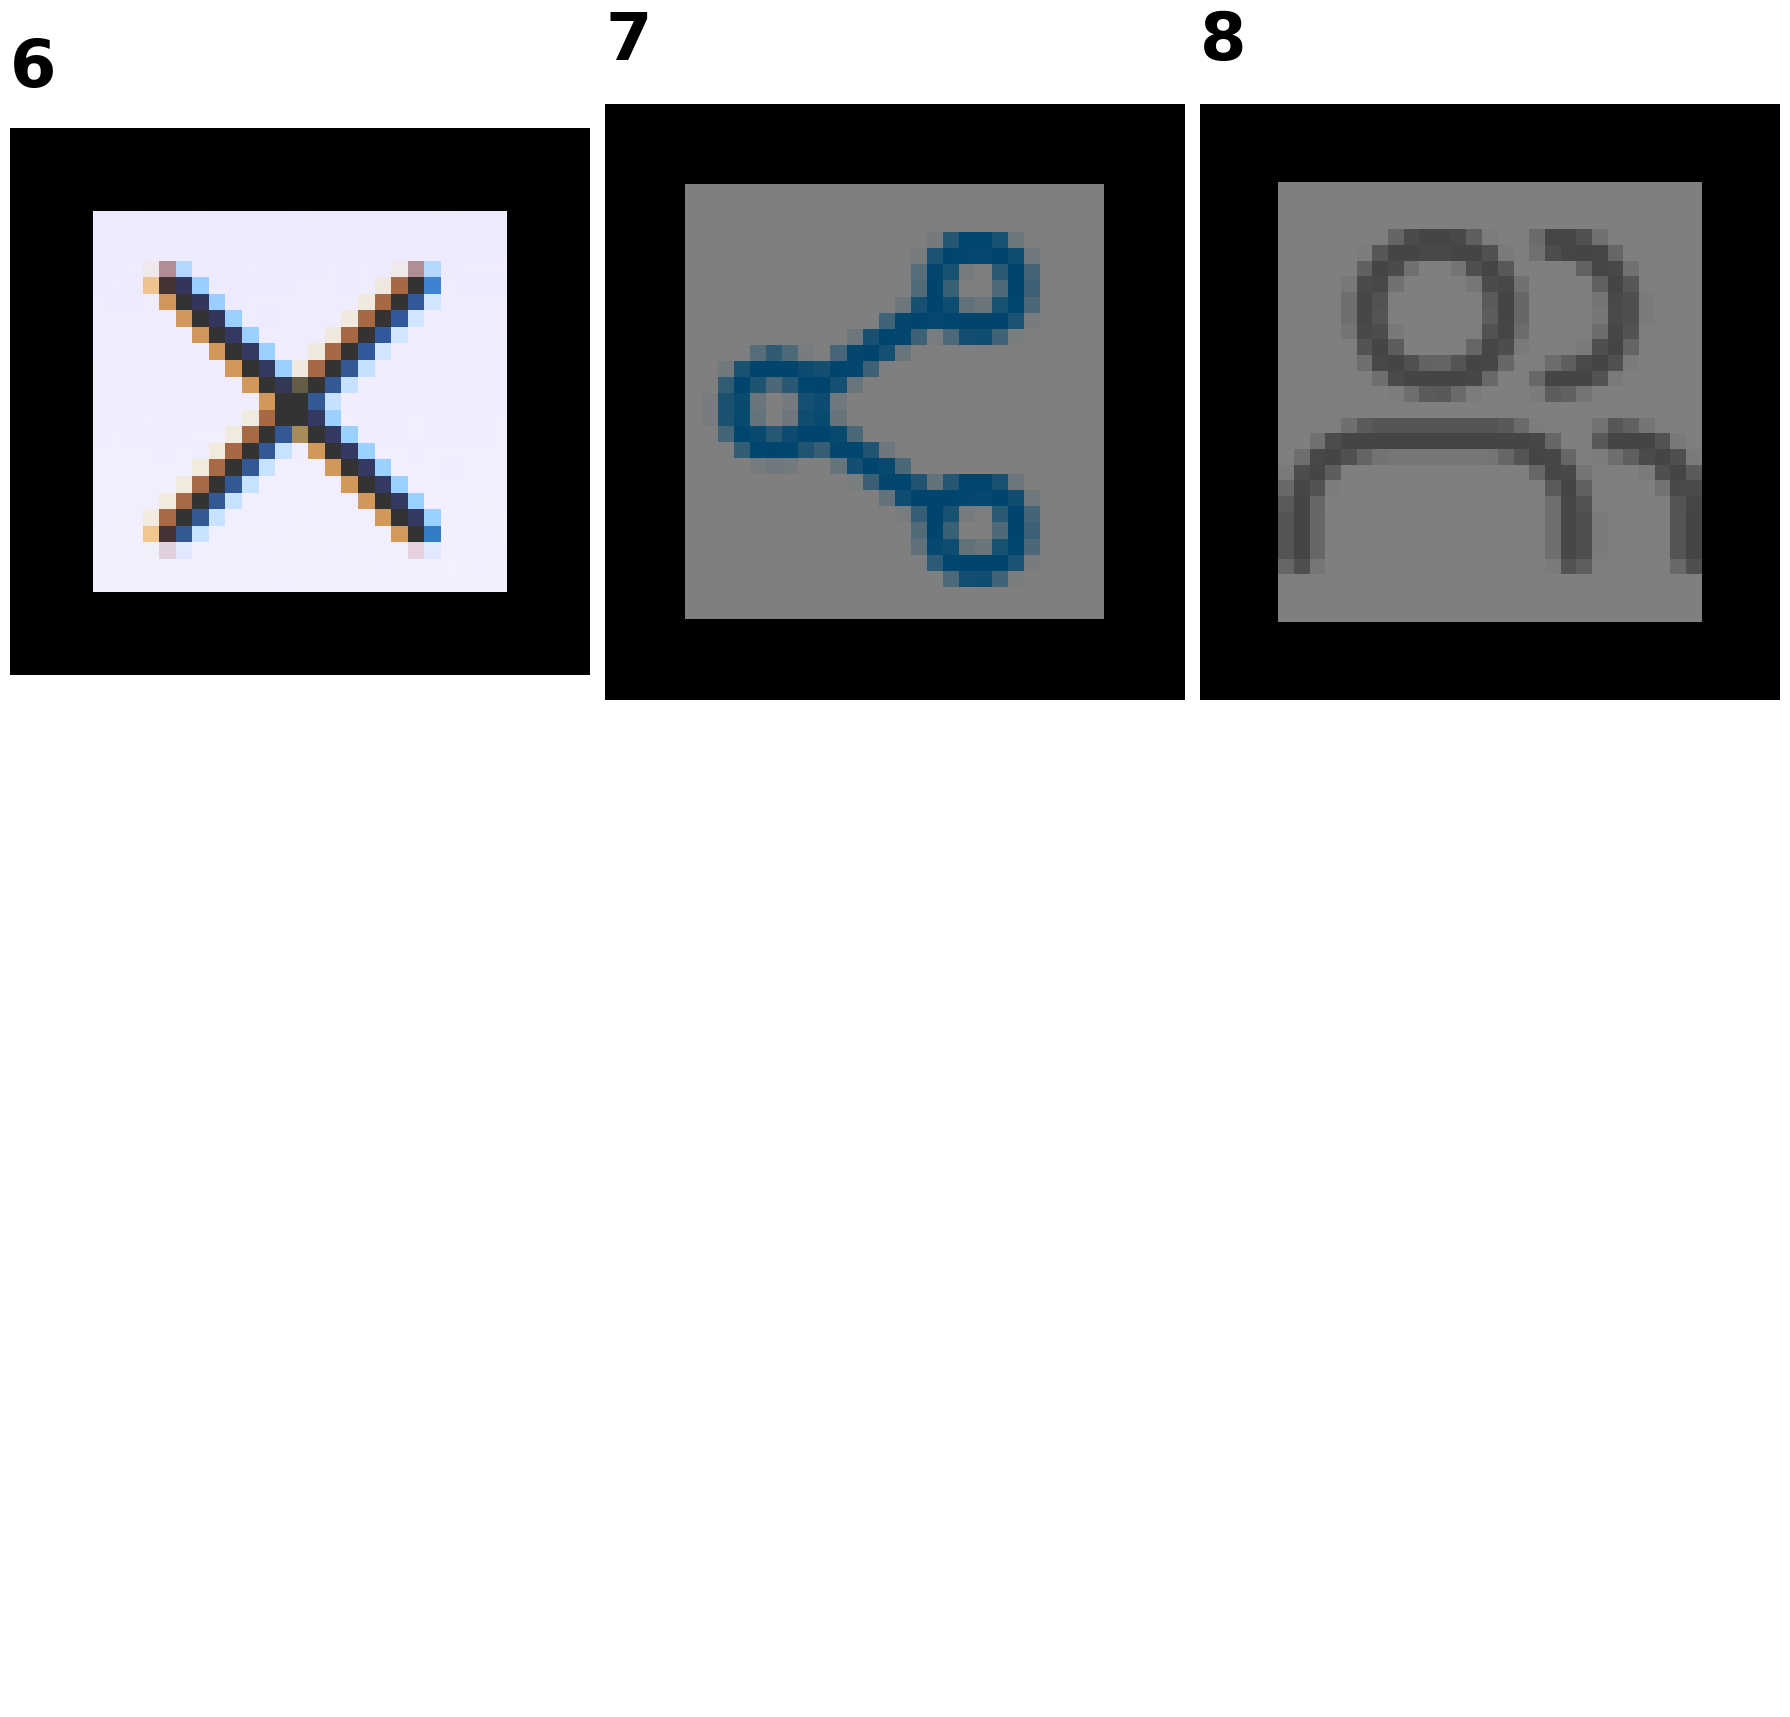

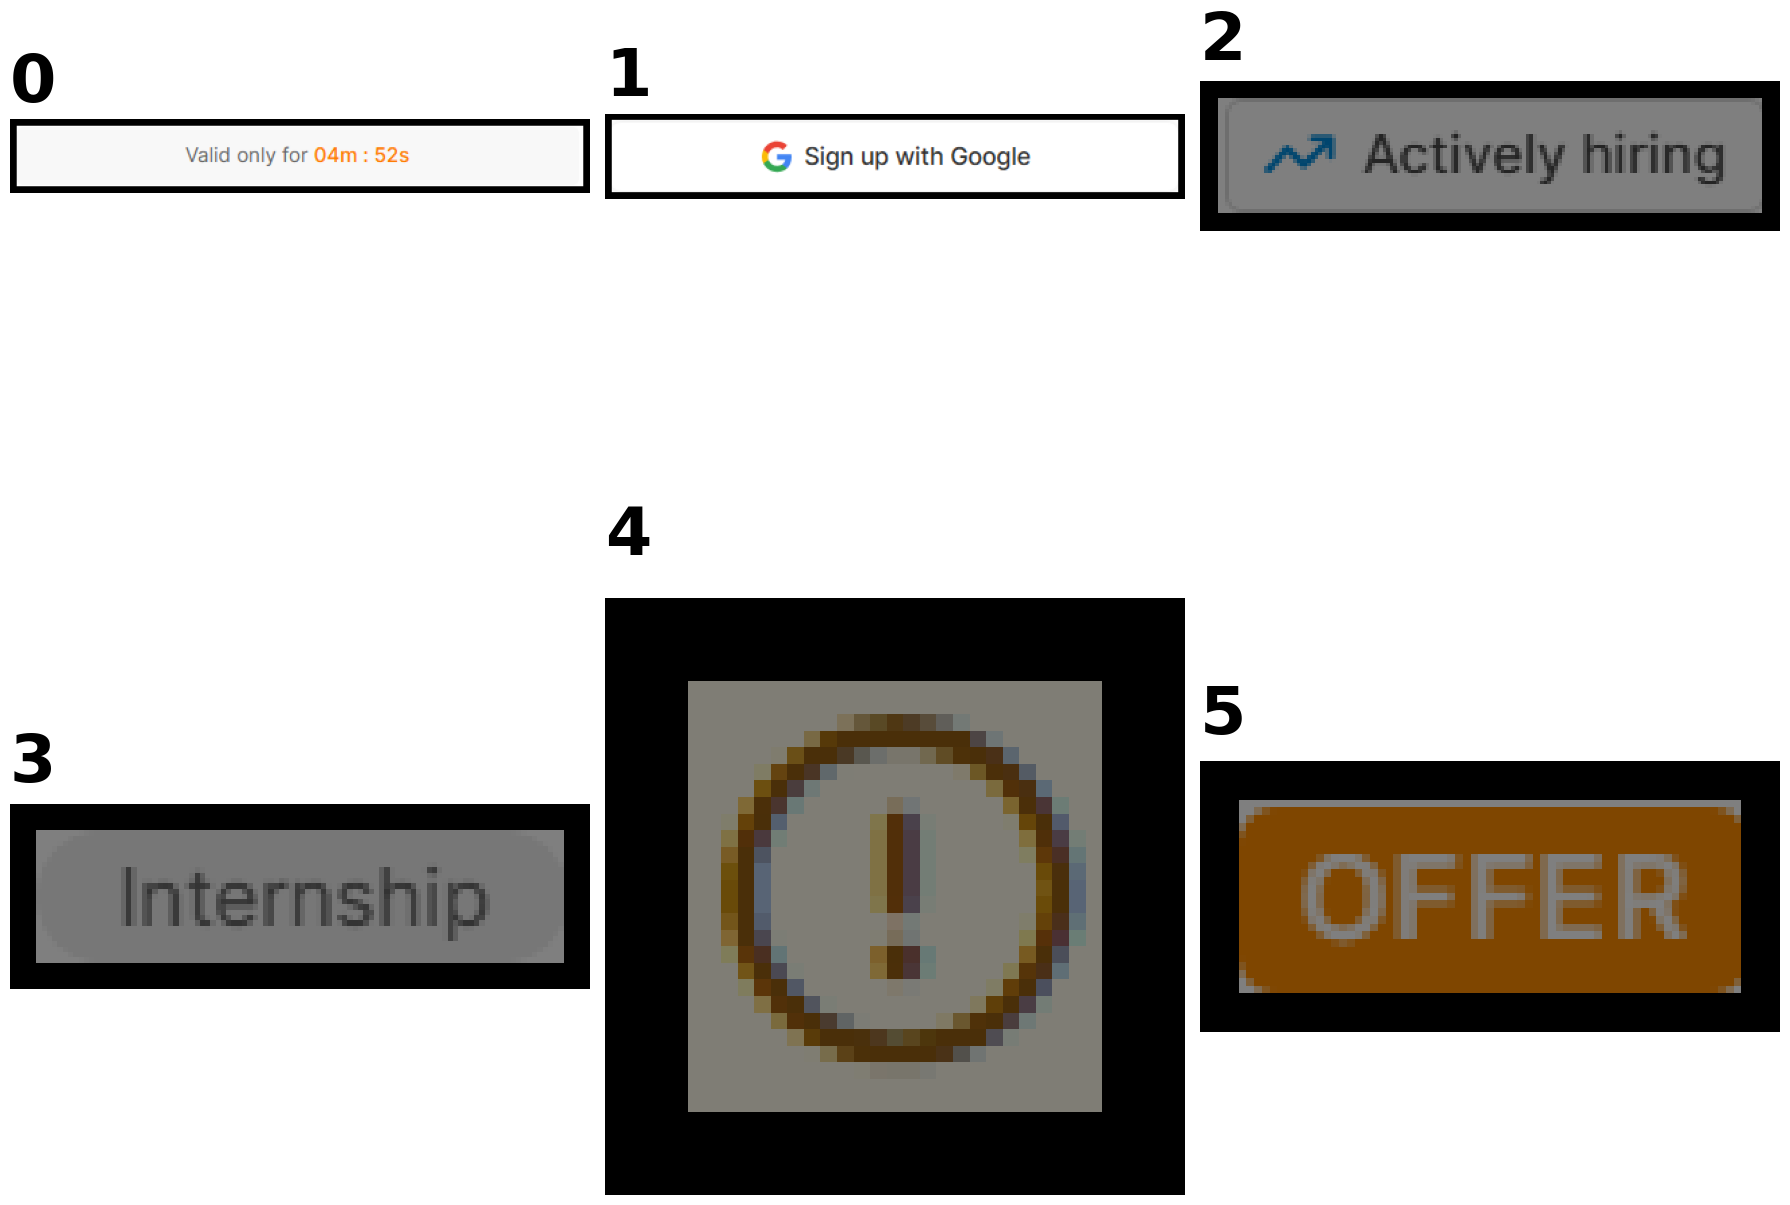

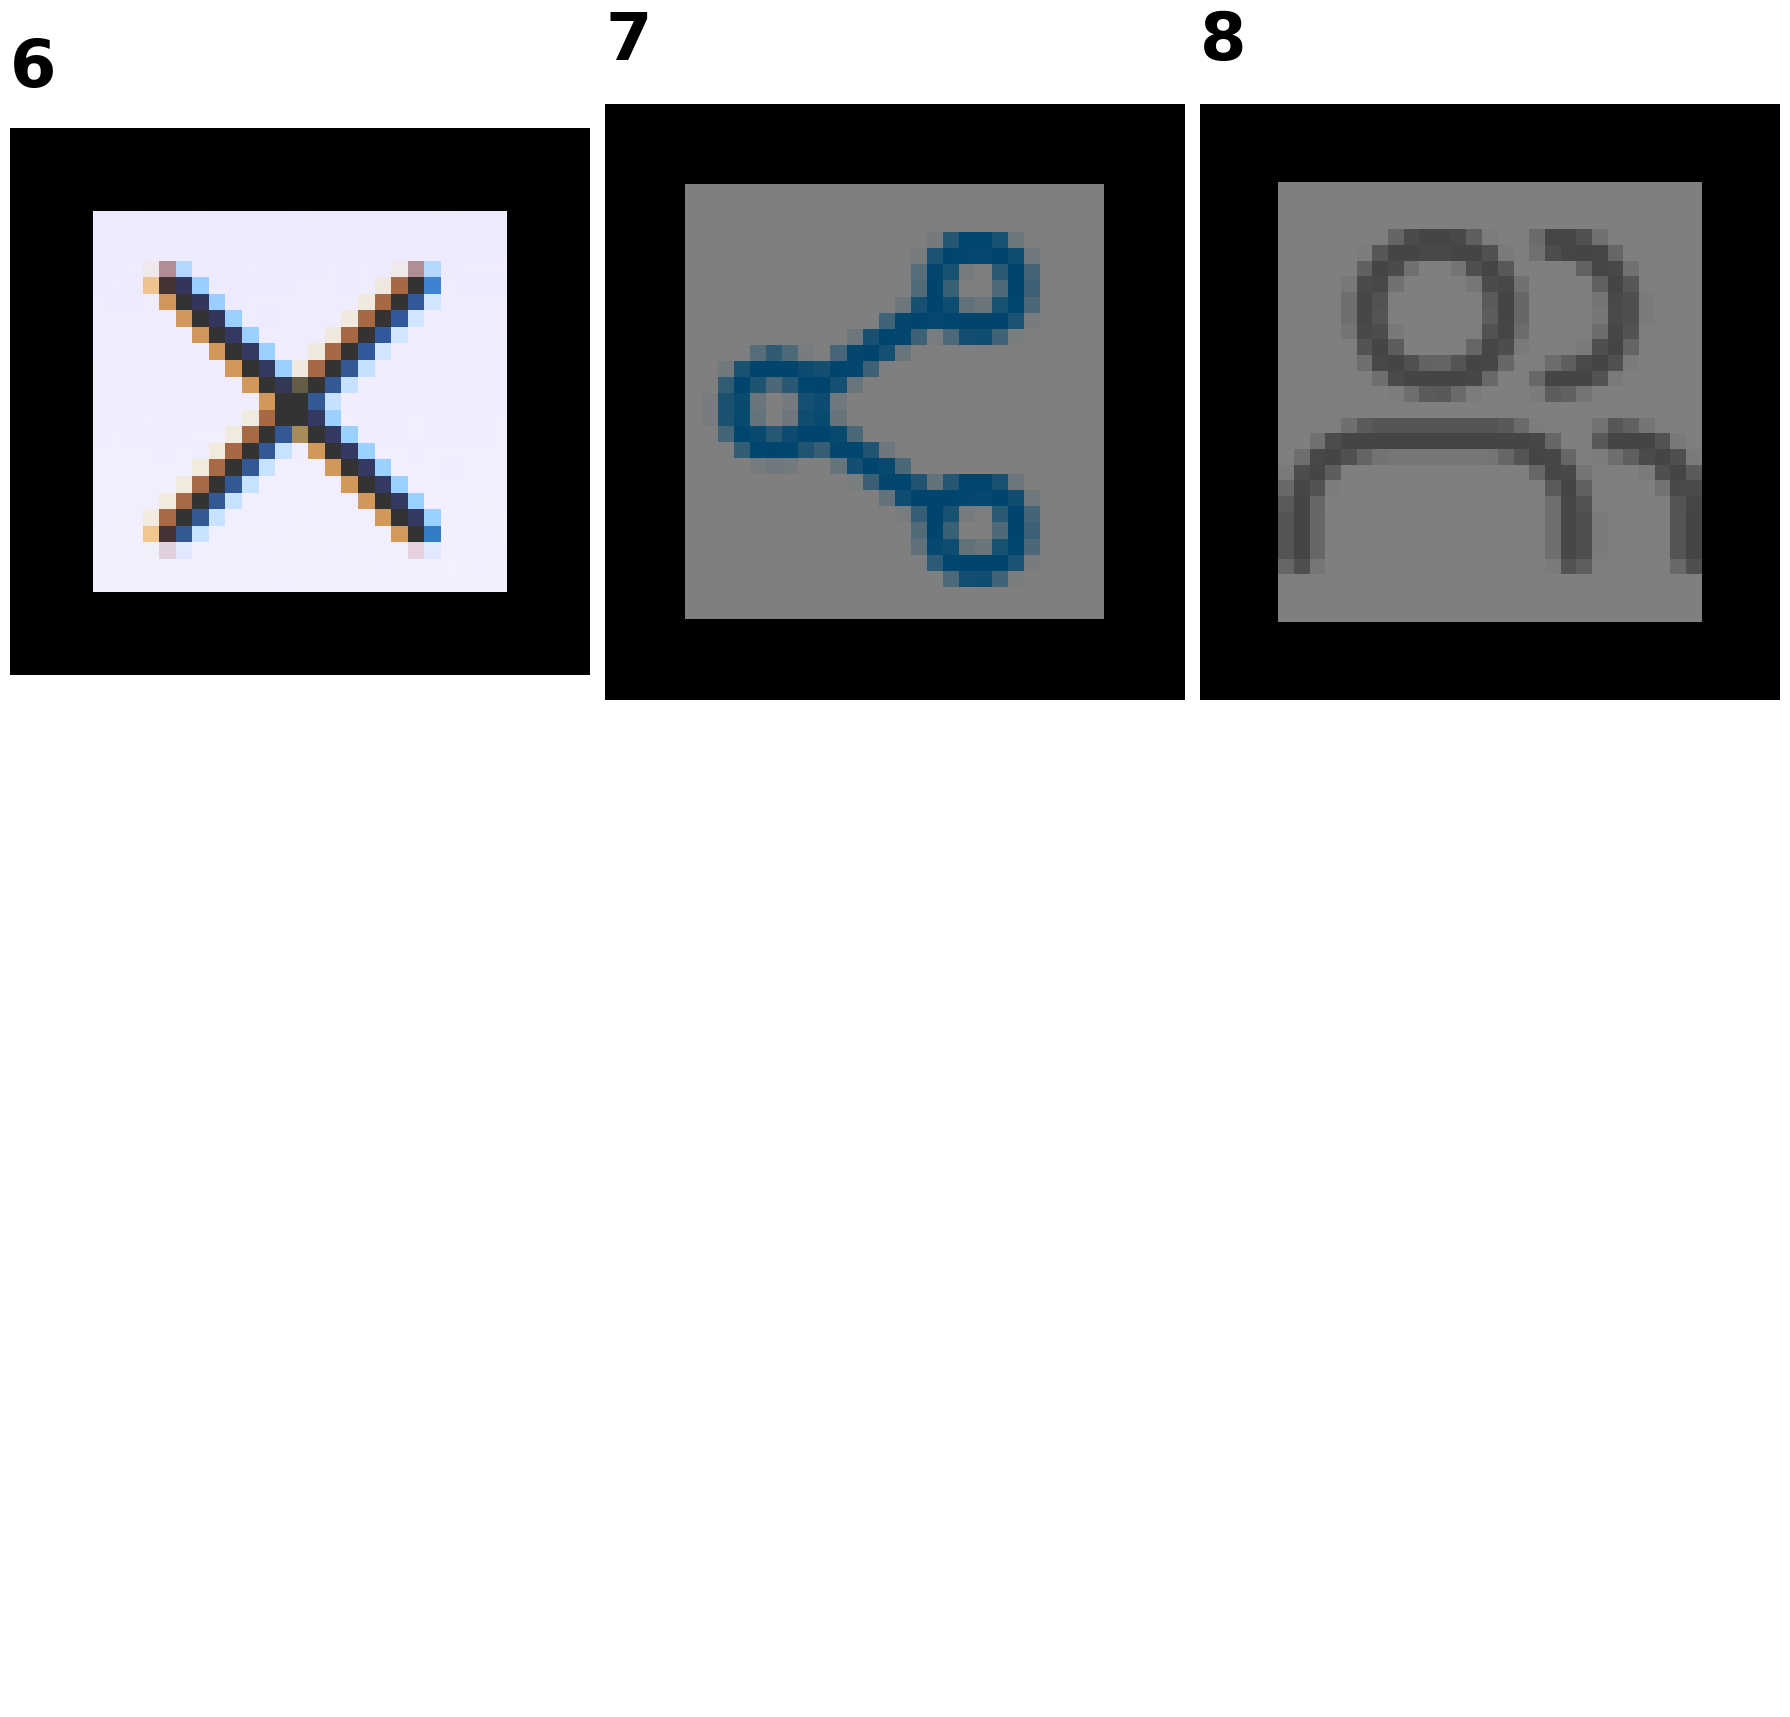

In [18]:
driver_path = r"chromedriver.exe"


service = Service(driver_path)
driver = webdriver.Chrome(service=service)



@tool
def find_visual_element_index(image_button_to_be_clicked:str)->None:
    """
    Locate the index of an interactive webpage element using visual understanding.

    Use this tool when the target cannot be reliably identified from its DOM attributes
    or visible text alone and must instead be recognized by its appearance, shape,
    symbol, iconography, styling, or surrounding visual context.

    This tool is intended for graphical controls whose meaning is conveyed primarily
    through the rendered webpage rather than textual information.

    Provide a concise natural language description of the desired element.

    Returns the index of the best matching interactive element from the current webpage.
    """
    output=app.invoke({
        "driver": driver,
        "explanation":image_button_to_be_clicked,
        "image_path":global_image_path_for_ss
    })

    print(output)
    return "Done clicking the icon"



@tool
def find_text_based_element_index(button_to_be_clicked:str)->None:
    """
    Find the index of the interactive webpage element that best matches a given description.

    Use this tool whenever you need to determine which element on the current webpage
    should be interacted with. The element may be a button, link, input field,
    dropdown, menu item, checkbox, icon, tab, card, or any other interactive component.

    Provide a natural language description of the intended interaction or target element.

    Returns the index of the most relevant element from the list of interactive
    elements currently available on the webpage.
    """
    prompt=ChatPromptTemplate.from_messages([("system", """
You are an expert web navigation assistant.

Your task is to identify the single most relevant interactive webpage element
that satisfies the user's intent.

You will receive:
1. A description of the action the user wants to perform.
2. A list of available interactive elements.

Each element contains:
- index
- element type
- visible text or label

Selection Rules:
- Prefer elements whose purpose most closely matches the user's intent.
- Consider the element text, label, and type.
- If multiple elements appear similar, choose the most specific match.
- Only select from the provided elements.
- Never invent an index.
- Return exactly one integer index.

Output Rules:
- Return only the index.
- Do not explain your reasoning.
- Do not include any additional text.
- Do not output JSON.
- Example valid outputs:
Index is: 0
Index is: 5
Index is: 12
"""), ("human", """User Intent:
{explanation}

Available Elements:
{buttons}"""), ("ai", "Index is: ")])
    
    answer=get_interactive_elements(driver)

    button_list=[]
    for idx, ele in enumerate(answer):
        if ele["aria_label"]!="":
            button_list.append(
                f'{ele["aria_label"]} of index {idx}'
            )
        elif ele["text"]!="":
            button_list.append(
                f'{ele["text"]} of index {idx}'
            )
        elif ele["placeholder"]!="":
            button_list.append(
                f'{ele["placeholder"]} of index {idx}'
            )
    chain=prompt | model | StrOutputParser()

    xpath=answer[int(str(chain.invoke({
        "explanation":button_to_be_clicked,
        "buttons":button_list
    })).strip())]["xpath"]
    


    driver.find_element(By.XPATH, xpath).click()
    return "DONE CLICKING"
tools=[find_text_based_element_index, find_visual_element_index]
from langchain.chains.base import Chain

class ss_custom_chain(Chain):
    @property
    def input_keys(self):
        return ["path"]

    @property
    def output_keys(self):
        return ["base64_image"]

    def _call(self, inputs, run_manager = None):
        driver.save_screenshot(inputs["path"])
        base64_image=encode_image(inputs["path"])
        return {"base64_image":base64_image}

ss_runnable2=ss_custom_chain()
prompt=ChatPromptTemplate.from_messages([("system", """You are an intelligent web navigation agent.

Your task is to analyze the current webpage screenshot and understand the state of the page.

Carefully identify:

- The purpose of the current page.
- Important visible text.
- Input fields and what information they request.
- Buttons, links, menus, tabs, dropdowns, and other interactive elements.
- Any forms that are present.
- Any dialogs, popups, alerts, or error messages.
- Information that may be relevant to completing the user's objective.

When describing elements, focus on how a human would identify them.

For each important interactive element, provide:
- Element type
- Visible text
- Purpose

Do not assume information that is not visible.

Use the previous observations and actions in the scratchpad to maintain context across steps.

Previous observations and actions:
"""), ("human", [{
        "type":"text",
        "text": "Analyze the following image"
    },
    {"type":"image", "image_url": {
        "url":"data:image/jpeg;base64,{base64_image}"}
    }]), MessagesPlaceholder("agent_scratchpad")])

init=create_tool_calling_agent(
    llm=vlm_model,
    tools=tools,
    prompt=prompt
)
agent=AgentExecutor(tools=tools, agent=init, verbose=True)

chain=ss_runnable2 | agent


driver.get("https://internshala.com/internship/detail/software-testing-internship-in-hyderabad-at-educase-india1778215471/")
time.sleep(3)
chain.invoke({
    "path":global_image_path_for_ss
})
